# Homework 6

# Part A

In [1]:
# HW6 Logistic Regression — Part A

import pandas as pd
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

# Load data
titanic = pd.read_csv("titanic.csv")

# Keep useful variables
titanic_model = titanic[
    ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
].copy()

# Remove rows with missing values
titanic_model = titanic_model.dropna()

# Fit logistic regression
# C() tells Python to treat these as categorical variables
model = smf.logit(
    "Survived ~ C(Pclass) + C(Sex) + Age + SibSp + Parch + Fare + C(Embarked)",
    data=titanic_model
).fit()

# Report coefficients
print(model.summary())

# Predicted probabilities
pred_prob = model.predict(titanic_model)

# Classify using 0.5 cutoff
pred_class = (pred_prob >= 0.5).astype(int)

# Confusion matrix
conf_matrix = confusion_matrix(titanic_model["Survived"], pred_class)

print("\nConfusion Matrix:")
print(conf_matrix)

# Classification metrics
accuracy = accuracy_score(titanic_model["Survived"], pred_class)
precision_survived = precision_score(titanic_model["Survived"], pred_class)
recall_survived = recall_score(titanic_model["Survived"], pred_class)

print("\nClassification Metrics:")
print("Accuracy:", accuracy)
print("Precision for survived:", precision_survived)
print("Recall for survived:", recall_survived)

Optimization terminated successfully.
         Current function value: 0.444060
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  712
Model:                          Logit   Df Residuals:                      702
Method:                           MLE   Df Model:                            9
Date:                Thu, 09 Jul 2026   Pseudo R-squ.:                  0.3419
Time:                        13:04:07   Log-Likelihood:                -316.17
converged:                       True   LL-Null:                       -480.45
Covariance Type:            nonrobust   LLR p-value:                 2.249e-65
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            4.4329      0.536      8.271      0.000       3.383       5.483
C(Pclass)[T

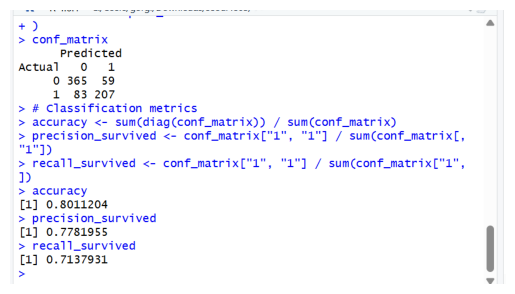

In [10]:
img = Image.open(r"C:\Users\gorgi\Downloads\Screenshot 2026-07-09 133622.png")

plt.imshow(img)
plt.axis("off")
plt.show()

# Part B

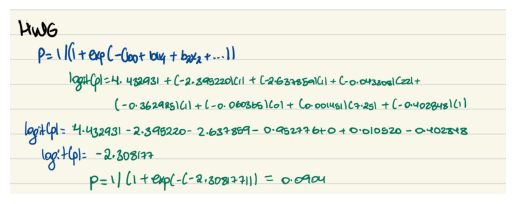

In [3]:
from PIL import Image
import matplotlib.pyplot as plt
img = Image.open(r"C:\Users\gorgi\Downloads\Image (1).jpeg")

plt.imshow(img)
plt.axis("off")
plt.show()

# Part C

In [5]:
# Load data
titanic = pd.read_csv("titanic.csv")

# Keep useful variables
titanic_model = titanic[
    ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
].copy()

# Remove rows with missing values
titanic_model = titanic_model.dropna()

# Fit logistic regression
model = smf.logit(
    "Survived ~ C(Pclass) + C(Sex) + Age + SibSp + Parch + Fare + C(Embarked)",
    data=titanic_model
).fit()

# Predicted probabilities
pred_prob = model.predict(titanic_model)

# Classify using 0.5 cutoff
pred_class = (pred_prob >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(titanic_model["Survived"], pred_class)

print("Confusion Matrix:")
print(cm)

# Model classification metrics
accuracy = accuracy_score(titanic_model["Survived"], pred_class)
precision_survived = precision_score(titanic_model["Survived"], pred_class, pos_label=1)
recall_survived = recall_score(titanic_model["Survived"], pred_class, pos_label=1)

print("\nModel Metrics:")
print("Accuracy:", accuracy)
print("Precision for survived:", precision_survived)
print("Recall for survived:", recall_survived)

# Class balance
class_counts = titanic_model["Survived"].value_counts().sort_index()

print("\nClass Balance:")
print(class_counts)

# Majority-class baseline: always predict 0 = did not survive
majority_accuracy = class_counts.max() / class_counts.sum()

print("\nMajority-class baseline accuracy:")
print(majority_accuracy)

Optimization terminated successfully.
         Current function value: 0.444060
         Iterations 6
Confusion Matrix:
[[365  59]
 [ 83 205]]

Model Metrics:
Accuracy: 0.800561797752809
Precision for survived: 0.7765151515151515
Recall for survived: 0.7118055555555556

Class Balance:
Survived
0    424
1    288
Name: count, dtype: int64

Majority-class baseline accuracy:
0.5955056179775281


The AI’s conclusion is misleading because accuracy alone does not prove that the model is an excellent predictor. If one class is more common, a model can look good by mostly predicting the majority class. So we should compare the model to the majority-class baseline and also look at precision and recall for the minority class.

Confusion matrix:

Actual 0, Predicted 0 = 365  
Actual 0, Predicted 1 = 59  
Actual 1, Predicted 0 = 83  
Actual 1, Predicted 1 = 205  

Class balance:

Did not survive, Survived = 0: 424 passengers  
Survived, Survived = 1: 288 passengers  
Total: 712 passengers  

424 / 712 = 0.5955

So the majority-class baseline accuracy is about 59.55%. Meaning always predicts survived =0

The logistic regression model accuracy is:

(365 + 205) / 712 = 0.8006

So the model accuracy is about 80.06%.

For the minority class, Survived = 1:

Precision = 205 / (205 + 59) = 0.7765

Recall = 205 / (205 + 83) = 0.7118

So the model has about 77.65% precision and 71.18% recall for predicting survival.

Therefore, the AI’s claim that the model is excellent just because it has high accuracy is misleading. The model is better than the majority-class baseline, but accuracy alone is not enough. A more honest evaluation uses the confusion matrix, precision, and recall for the minority class.

# Part D

The model shows that survival is mostly driven by passenger class, sex, age, family size, fare, and where the passenger embarked. Based on the coefficients, being male lowers the chance of survival, and being in a lower passenger class also lowers the chance of survival. This means the model is picking up patterns like women and higher-class passengers having higher survival chances.
Logistic regression is the right tool because the outcome is 0 or 1, meaning survived or did not survive. Linear regression is not the best choice because it can predict values below 0 or above 1, which does not make sense for probability. Logistic regression keeps the prediction between 0 and 1, so it works better for predicting survival probability.
If someone wanted to use this model for real triage decisions, I would say to be very careful. The model can show patterns in the data, but it should not be the only thing used to make life-or-death decisions. It can be biased because it is based on historical data, so a person should review the model results and use human judgment too.